# Master Model Comparison — Predicting Daily Change in Polymarket Trump Probability

This notebook aggregates test-set results from every model notebook and answers two questions:
1. **Which is the best model overall?** (primary: Directional Accuracy, secondary: MAE)
2. **How do different feature sets and model types compare?**

## 1. Setup

In [71]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm

from house_style import (
    apply_style, BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED,
    SPINE_COLOR, GRID_COLOR, DEMOCRAT, REPUBLICAN, NEUTRAL, PALETTE,
)
apply_style()

print("Setup OK")

Setup OK


## 2. Test-Set Results

Results are loaded automatically from `results/*.csv` — re-run any model notebook to update its CSV, then re-run this notebook.

**All linear models use Ridge Regression** (L2-regularised, alpha tuned via walk-forward CV). All 8 feature sets use the same 4 models: Ridge, Random Forest, SVM, XGBoost.

In [72]:
from pathlib import Path

# ── Naive baseline (identical across all feature sets — same test split) ──────
NAIVE = {"MAE": 0.0162, "RMSE": 0.0208, "DA": 0.0000, "R2": -0.0570}

# ── Load per-notebook results from CSV ───────────────────────────────────────
RESULTS_DIR = Path("results")

# Maps CSV feature_set label → display label used in charts (with \n for wrapping)
LABEL_MAP = {
    "Lag (2f)"          : "Lag\n(2f)",
    "Social (61f)"      : "Social\n(61f)",
    "Web+Polls (19f)"   : "Web+Polls\n(19f)",
    "Traditional (19f)" : "Traditional\n(19f)",
    "Financial (10f)"   : "Financial\n(10f)",
    "Lag+Social (64f)"  : "Lag+Social\n(64f)",
    "Lag+Soc+Trad (83f)": "Lag+Soc+Trad\n(83f)",
    "Full (111f)"       : "Full\n(111f)",
}

csv_files = sorted(RESULTS_DIR.glob("*.csv"))
assert csv_files, f"No CSV files found in {RESULTS_DIR} — run all model notebooks first."

df_loaded = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df_loaded["Feature set"] = df_loaded["Feature_set"].map(LABEL_MAP).fillna(df_loaded["Feature_set"])

# ── Reconstruct RAW dict (same structure as before, for chart compatibility) ──
df_models = df_loaded[df_loaded["Model"] != "Naive (zero)"].copy()

RAW = {}
for fset_display, grp in df_models.groupby("Feature set", sort=False):
    RAW[fset_display] = {
        row["Model"]: {"MAE": row["MAE"], "RMSE": row["RMSE"], "DA": row["DA"], "R2": row["R2"]}
        for _, row in grp.iterrows()
    }

# ── Build long-form DataFrame ─────────────────────────────────────────────────
rows = []
for fset, models in RAW.items():
    for model, m in models.items():
        rows.append({"Feature set": fset, "Model": model, **m})

df_all = pd.DataFrame(rows)

# ── Pivot tables for heatmaps ─────────────────────────────────────────────────
da_pivot  = df_all.pivot(index="Model", columns="Feature set", values="DA")
mae_pivot = df_all.pivot(index="Model", columns="Feature set", values="MAE")
r2_pivot  = df_all.pivot(index="Model", columns="Feature set", values="R2")

print(f"Loaded {len(csv_files)} result file(s) from '{RESULTS_DIR}/'")
print(f"Models tracked : {df_all['Model'].nunique()} types")
print(f"Feature sets   : {df_all['Feature set'].nunique()}")
print(f"Total entries  : {len(df_all)}")
print(f"\nNaive baseline : MAE={NAIVE['MAE']:.4f}, DA={NAIVE['DA']:.4f}")
print("\nFeature sets loaded:")
for fs, models in RAW.items():
    print(f"  {fs.replace(chr(10), ' '):<28} → {list(models.keys())}")

Loaded 8 result file(s) from 'results/'
Models tracked : 4 types
Feature sets   : 8
Total entries  : 32

Naive baseline : MAE=0.0162, DA=0.0000

Feature sets loaded:
  Financial (10f)              → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Full (111f)                  → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Lag (2f)                     → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Lag+Soc+Trad (83f)           → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Lag+Social (64f)             → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Social (61f)                 → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Traditional (19f)            → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']
  Web+Polls (19f)              → ['Ridge', 'Random Forest', 'SVM', 'XGBoost']


## 3. Complete Results Table

All models × feature sets. Sorted by Directional Accuracy (primary) then MAE (secondary).  
Naive baseline: MAE = 0.0162, DA = 0.000, R² = −0.057.

In [73]:
df_sorted = (
    df_all
    .sort_values(["DA", "MAE"], ascending=[False, True])
    .reset_index(drop=True)
)
df_sorted.index += 1
df_sorted["Feature set"] = df_sorted["Feature set"].str.replace("\n", " ")

print("All model-feature combinations — ranked by DA (↓) then MAE (↑):")
display(
    df_sorted[["Feature set", "Model", "DA", "MAE", "RMSE", "R2"]]
    .style
    .format({"DA": "{:.4f}", "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
    .highlight_max(subset=["DA"], color="#2a5c2a")
    .highlight_min(subset=["MAE"], color="#2a5c2a")
)

All model-feature combinations — ranked by DA (↓) then MAE (↑):


,Feature set,Model,DA,MAE,RMSE,R2
1,Full (111f),SVM,0.5714,0.0143,0.0209,-0.0657
2,Full (111f),Ridge,0.5714,0.0155,0.0208,-0.0577
3,Lag+Soc+Trad (83f),Ridge,0.5714,0.0156,0.0210,-0.0757
4,Web+Polls (19f),XGBoost,0.5714,0.0156,0.0196,0.0569
5,Lag+Social (64f),Ridge,0.5714,0.0158,0.0210,-0.0788
6,Financial (10f),SVM,0.5714,0.0160,0.0202,0.0021
7,Lag+Soc+Trad (83f),XGBoost,0.5714,0.0160,0.0208,-0.0645
8,Full (111f),XGBoost,0.5714,0.0161,0.0208,-0.0592
9,Social (61f),XGBoost,0.5714,0.0161,0.0212,-0.0994
10,Lag (2f),XGBoost,0.5714,0.0162,0.0200,0.0165


## 4. Best Model per Feature Set

For each feature set, the best model is selected by: highest DA → lowest MAE as tiebreaker.  
OLS models are included as-is — note that OLS has poor CV performance but can still score well on the 14-day test set.

In [74]:
best_rows = []
for fset, models in RAW.items():
    best_model = max(models.items(), key=lambda kv: (kv[1]["DA"], -kv[1]["MAE"]))
    best_rows.append({
        "Feature set": fset.replace("\n", " "),
        "Best model"  : best_model[0],
        "DA"          : best_model[1]["DA"],
        "MAE"         : best_model[1]["MAE"],
        "RMSE"        : best_model[1]["RMSE"],
        "R2"          : best_model[1]["R2"],
    })

df_best = pd.DataFrame(best_rows).sort_values(["DA", "MAE"], ascending=[False, True]).reset_index(drop=True)
df_best.index += 1

print("Best model per feature set (ranked by DA → MAE):")
display(
    df_best.style
    .format({"DA": "{:.4f}", "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
    .highlight_max(subset=["DA"], color="#2a5c2a")
    .highlight_min(subset=["MAE"], color="#2a5c2a")
)

Best model per feature set (ranked by DA → MAE):


,Feature set,Best model,DA,MAE,RMSE,R2
1,Full (111f),SVM,0.5714,0.0143,0.0209,-0.0657
2,Lag+Soc+Trad (83f),Ridge,0.5714,0.0156,0.0210,-0.0757
3,Web+Polls (19f),XGBoost,0.5714,0.0156,0.0196,0.0569
4,Lag+Social (64f),Ridge,0.5714,0.0158,0.0210,-0.0788
5,Financial (10f),SVM,0.5714,0.0160,0.0202,0.0021
6,Social (61f),XGBoost,0.5714,0.0161,0.0212,-0.0994
7,Lag (2f),XGBoost,0.5714,0.0162,0.0200,0.0165
8,Traditional (19f),Ridge,0.5000,0.0160,0.0208,-0.0645


### 4a. MAE per Feature Set — Best Model Only

Each bar = the best model for that feature set (selected by DA → MAE).  
Ordered from fewest to most features (left → right). Dashed line = naive baseline (0.0162). Δ = difference vs naive.

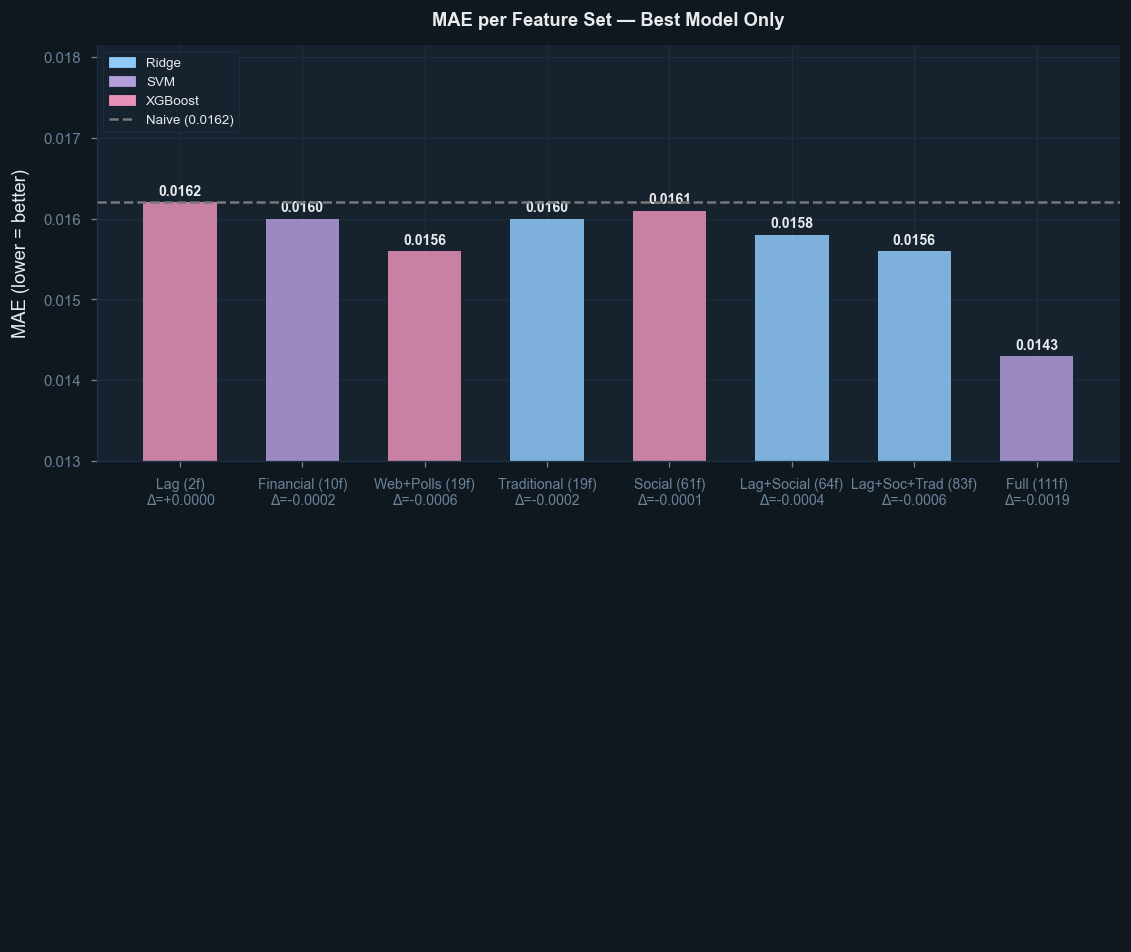

In [75]:
# ── 4a: MAE per feature set — best model, ordered by feature count ───────────
# Muted blue-family palette — desaturated for a softer, dusty feel
MODEL_COLORS = {
    "Ridge"        : "#90caf9",   # dusty sky blue
    "Random Forest": "#7986cb",   # muted periwinkle/indigo
    "SVM"          : "#b39ddb",   # soft lavender
    "XGBoost"      : "#e991b8",   # dusty rose/mauve
}

FSET_ORDER = [
    "Lag (2f)", "Financial (10f)", "Web+Polls (19f)", "Traditional (19f)",
    "Social (61f)", "Lag+Social (64f)", "Lag+Soc+Trad (83f)", "Full (111f)",
]
_order_map = {fs: i for i, fs in enumerate(FSET_ORDER)}

df_best_ordered = (
    df_best.copy()
    .assign(_order=df_best["Feature set"].map(_order_map))
    .sort_values("_order")
    .reset_index(drop=True)
)

fset_labels = df_best_ordered["Feature set"].tolist()
mae_vals    = df_best_ordered["MAE"].tolist()
model_names = df_best_ordered["Best model"].tolist()
bar_colors  = [MODEL_COLORS.get(m, TEXT_MUTED) for m in model_names]
delta_vals  = [v - NAIVE["MAE"] for v in mae_vals]

fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

bars = ax.bar(range(len(fset_labels)), mae_vals, color=bar_colors, alpha=0.85, width=0.6)

for i, (v, m) in enumerate(zip(mae_vals, model_names)):
    ax.text(i, v + 0.00005, f"{v:.4f}", ha="center", va="bottom",
            fontsize=8.5, color=TEXT_PRIMARY, fontweight="bold")
    ax.text(i, v / 2, m, ha="center", va="center",
            fontsize=7.5, color=BG_DARK, fontweight="bold")

ax.axhline(NAIVE["MAE"], color=NEUTRAL, linewidth=1.5, linestyle="--",
           label=f"Naive baseline ({NAIVE['MAE']:.4f})", zorder=3)

ax.set_xticks(range(len(fset_labels)))
ax.set_xticklabels(
    [f"{fs}\nΔ={d:+.4f}" for fs, d in zip(fset_labels, delta_vals)],
    color=TEXT_PRIMARY, fontsize=8.5
)
ax.set_ylabel("MAE (lower = better)", color=TEXT_PRIMARY)
ax.set_title("MAE per Feature Set — Best Model Only",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=11)

model_patches_mae = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()
                     if m in model_names]
ax.legend(handles=model_patches_mae + [
    plt.Line2D([0], [0], color=NEUTRAL, linewidth=1.5, linestyle="--", label=f"Naive ({NAIVE['MAE']:.4f})")
], loc="upper left", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
   labelcolor=TEXT_PRIMARY, fontsize=8)

ax.set_ylim(0.013, max(mae_vals) * 1.12)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 4b. Directional Accuracy per Feature Set — Best Model Only

Each bar = the best model for that feature set.  
Ordered from fewest to most features (left → right). Dashed line = coin flip (0.50). Dotted line = naive (0.00).  
Numbers inside bars show correct predictions out of 14 test days.

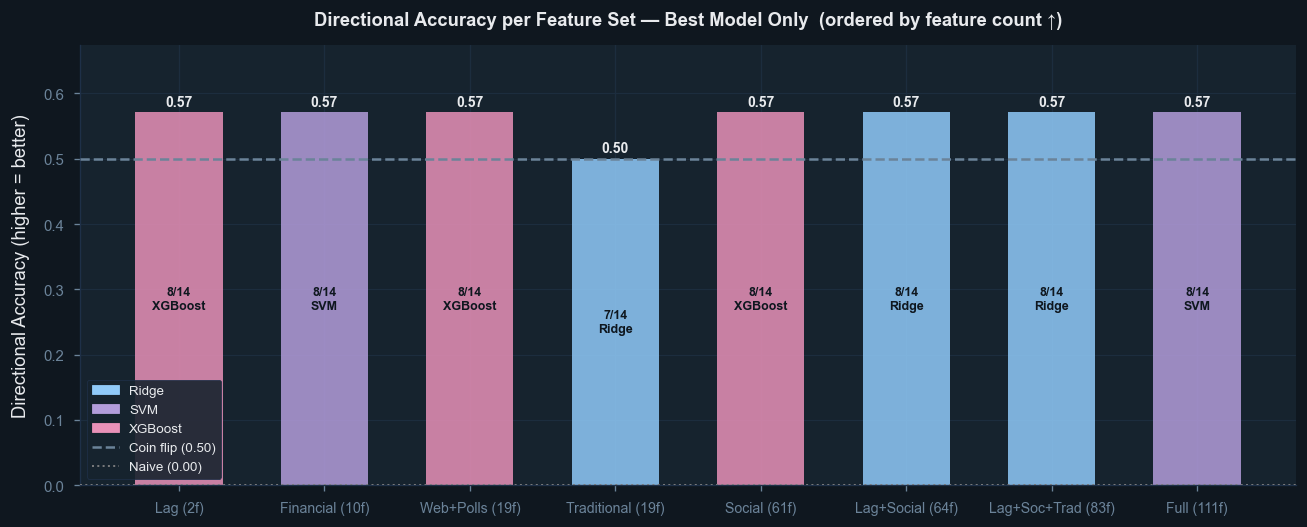

In [76]:
# ── 4b: DA per feature set — best model, ordered by feature count ────────────
df_best_ordered_da = (
    df_best.copy()
    .assign(_order=df_best["Feature set"].map(_order_map))
    .sort_values("_order")
    .reset_index(drop=True)
)

fset_labels_da = df_best_ordered_da["Feature set"].tolist()
da_vals        = df_best_ordered_da["DA"].tolist()
model_names_da = df_best_ordered_da["Best model"].tolist()
bar_colors_da  = [MODEL_COLORS.get(m, TEXT_MUTED) for m in model_names_da]
n_correct      = [round(v * 14) for v in da_vals]

fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

bars = ax.bar(range(len(fset_labels_da)), da_vals, color=bar_colors_da, alpha=0.85, width=0.6)

for i, (v, m, nc) in enumerate(zip(da_vals, model_names_da, n_correct)):
    ax.text(i, v + 0.005, f"{v:.2f}", ha="center", va="bottom",
            fontsize=8.5, color=TEXT_PRIMARY, fontweight="bold")
    if v > 0.15:
        ax.text(i, v / 2, f"{nc}/14\n{m}", ha="center", va="center",
                fontsize=7.5, color=BG_DARK, fontweight="bold")

ax.axhline(0.5,         color=TEXT_MUTED, linewidth=1.5, linestyle="--",
           label="Coin flip (0.50)", zorder=3)
ax.axhline(NAIVE["DA"], color=NEUTRAL,    linewidth=1.2, linestyle=":",
           label=f"Naive ({NAIVE['DA']:.2f})", zorder=3)

ax.set_xticks(range(len(fset_labels_da)))
ax.set_xticklabels(fset_labels_da, color=TEXT_PRIMARY, fontsize=8.5)
ax.set_ylabel("Directional Accuracy (higher = better)", color=TEXT_PRIMARY)
ax.set_title("Directional Accuracy per Feature Set — Best Model Only  (ordered by feature count ↑)",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=11)

model_patches_da = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()
                    if m in model_names_da]
ax.legend(handles=model_patches_da + [
    plt.Line2D([0], [0], color=TEXT_MUTED, linewidth=1.5, linestyle="--", label="Coin flip (0.50)"),
    plt.Line2D([0], [0], color=NEUTRAL,    linewidth=1.2, linestyle=":",  label="Naive (0.00)"),
], loc="lower left", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
   labelcolor=TEXT_PRIMARY, fontsize=8)

ax.set_ylim(0, max(da_vals) * 1.18)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 5. Directional Accuracy — All Models by Feature Set

Grouped bar chart. Each bar = one model type, groups = feature sets.  
Dashed line at 0.5 (coin flip). Models above this line correctly predict the *direction* of next-day movement more than half the time.

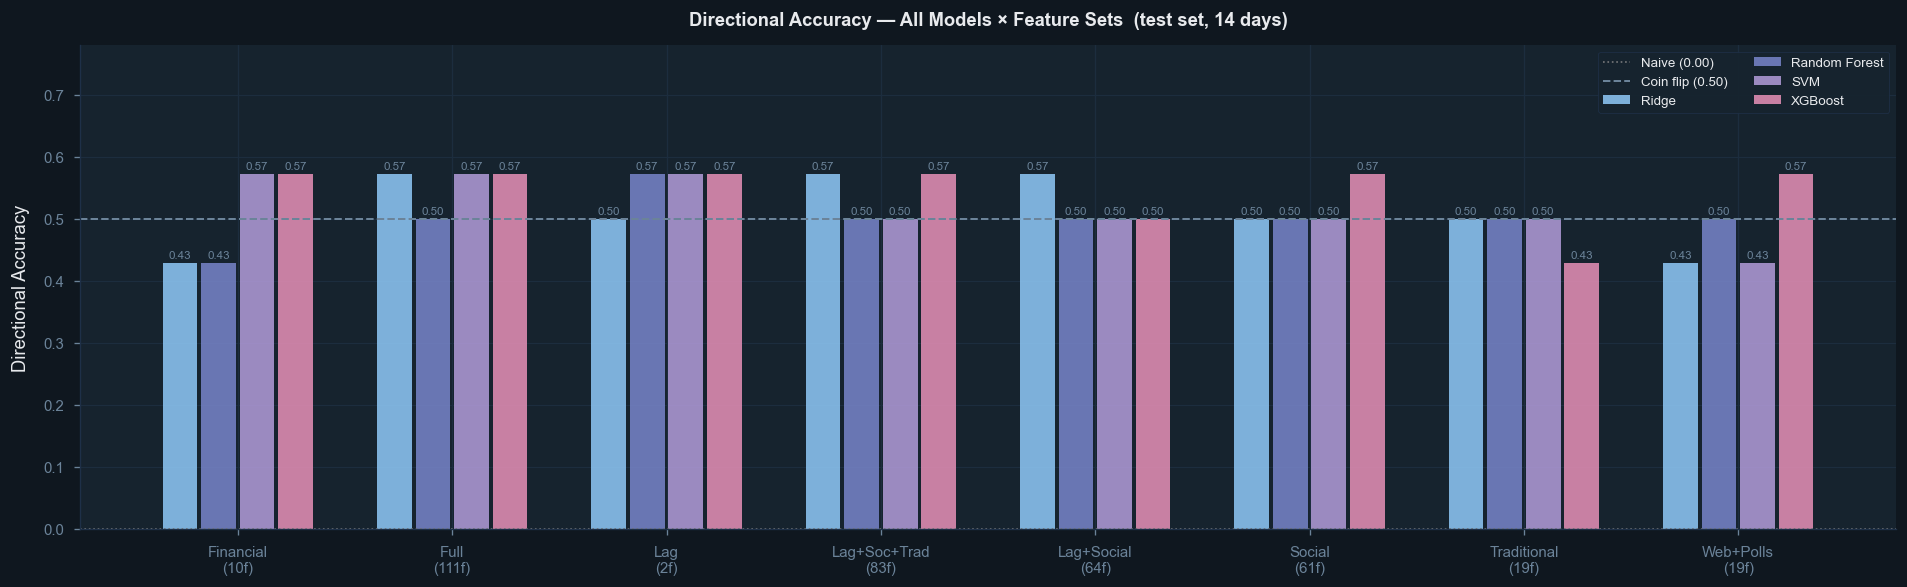

In [77]:
# Muted blue-family palette — desaturated for a softer, dusty feel
MODEL_COLORS = {
    "Ridge"        : "#90caf9",   # dusty sky blue
    "Random Forest": "#7986cb",   # muted periwinkle/indigo
    "SVM"          : "#b39ddb",   # soft lavender
    "XGBoost"      : "#e991b8",   # dusty rose/mauve
}

fsets      = list(RAW.keys())
all_models = ["Ridge", "Random Forest", "SVM", "XGBoost"]
n_fsets    = len(fsets)
n_models   = len(all_models)
x          = np.arange(n_fsets)
width      = 0.18
offsets    = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for i, (model, offset) in enumerate(zip(all_models, offsets)):
    vals = [RAW[fs].get(model, {}).get("DA", np.nan) for fs in fsets]
    bars = ax.bar(x + offset, vals, width=width * 0.9,
                  color=MODEL_COLORS[model], alpha=0.85, label=model)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7, color=TEXT_MUTED)

ax.axhline(NAIVE["DA"], color=NEUTRAL, linewidth=1.0, linestyle=":", label="Naive (0.00)")
ax.axhline(0.5,         color=TEXT_MUTED, linewidth=1.2, linestyle="--", label="Coin flip (0.50)")

ax.set_xticks(x)
ax.set_xticklabels([fs.replace("\n", "\n") for fs in fsets], color=TEXT_PRIMARY, fontsize=9)
ax.set_ylabel("Directional Accuracy", color=TEXT_PRIMARY)
ax.set_title("Directional Accuracy — All Models × Feature Sets  (test set, 14 days)",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=11)
ax.set_ylim(0, 0.78)
ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=8, ncol=2)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. MAE — All Models by Feature Set

Lower is better. Dashed line = naive baseline MAE (0.0162). OLS bars on combo/financial feature sets are truncated (their MAE exceeds the axis limit) — labelled with actual value.

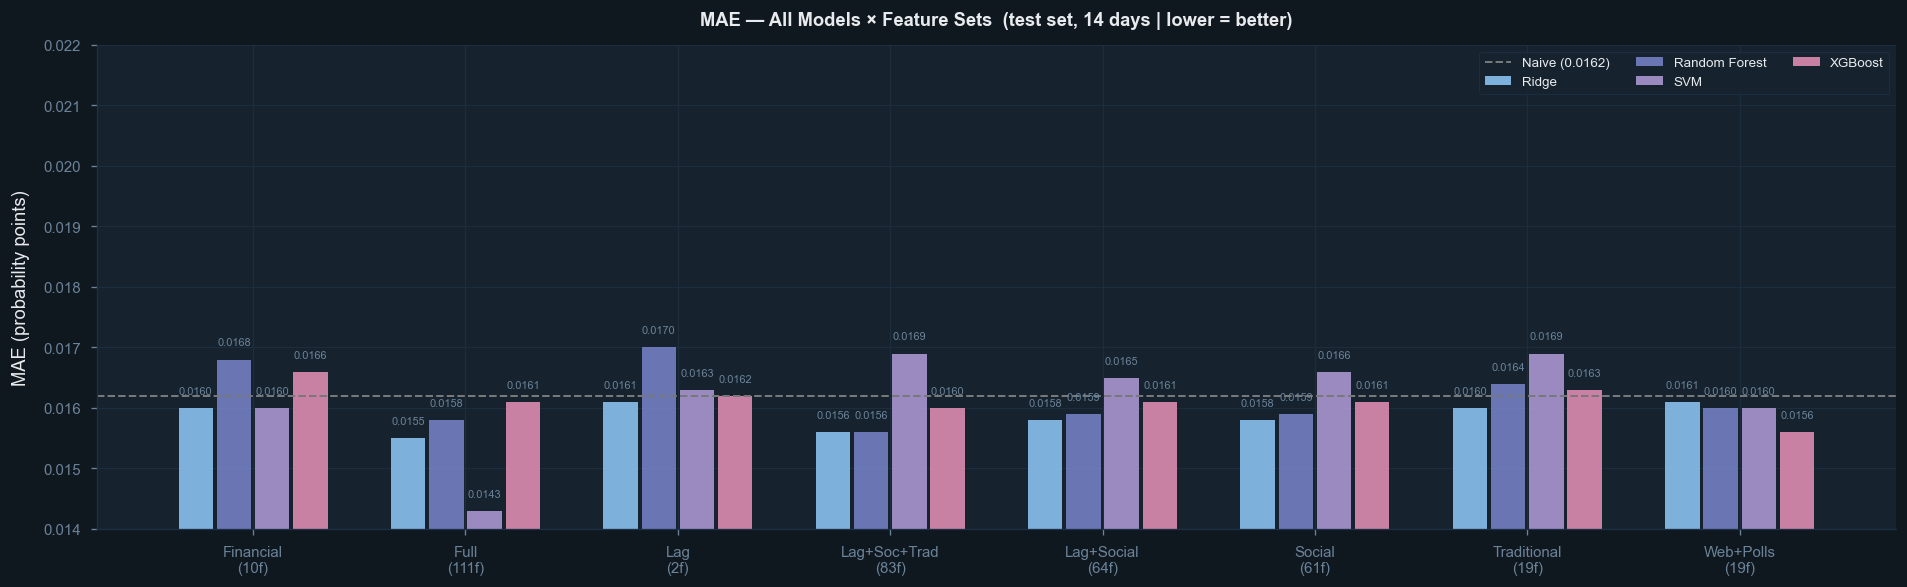

In [78]:
MAE_YLIM = 0.022

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for i, (model, offset) in enumerate(zip(all_models, offsets)):
    vals = [RAW[fs].get(model, {}).get("MAE", np.nan) for fs in fsets]
    plot_vals = [min(v, MAE_YLIM * 0.98) if not np.isnan(v) else np.nan for v in vals]
    bars = ax.bar(x + offset, plot_vals, width=width * 0.9,
                  color=MODEL_COLORS[model], alpha=0.85, label=model)
    for bar, v, pv in zip(bars, vals, plot_vals):
        if not np.isnan(v):
            label = f"{v:.4f}" if v <= MAE_YLIM else f"{v:.4f}↑"
            ax.text(bar.get_x() + bar.get_width() / 2, min(pv, MAE_YLIM * 0.97) + 0.0002,
                    label, ha="center", va="bottom", fontsize=6.5, color=TEXT_MUTED)

ax.axhline(NAIVE["MAE"], color=NEUTRAL, linewidth=1.2, linestyle="--", label=f"Naive ({NAIVE['MAE']:.4f})")

ax.set_xticks(x)
ax.set_xticklabels([fs for fs in fsets], color=TEXT_PRIMARY, fontsize=9)
ax.set_ylabel("MAE (probability points)", color=TEXT_PRIMARY)
ax.set_ylim(0.014, MAE_YLIM)
ax.set_title("MAE — All Models × Feature Sets  (test set, 14 days | lower = better)",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=11)
ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=8, ncol=3)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. DA vs MAE — All Individual Models

Each point is one (model, feature set) pair. The ideal corner is **top-left** (high DA, low MAE).  
Color = model type, marker shape = feature group (basic / combo).  
The grey cross marks the naive baseline.

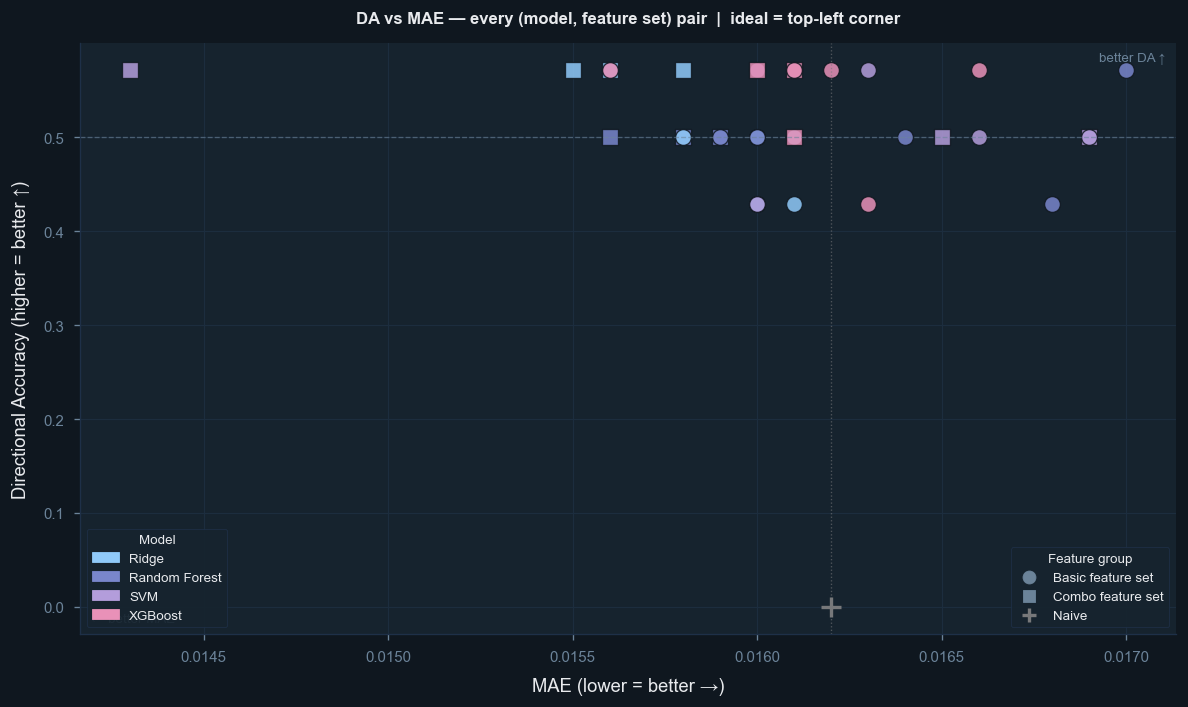

In [79]:
BASIC_FSETS = {"Lag\n(2f)", "Social\n(61f)", "Web+Polls\n(19f)", "Traditional\n(19f)", "Financial\n(10f)"}

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for _, row in df_all.iterrows():
    fset  = row["Feature set"]
    model = row["Model"]
    color = MODEL_COLORS.get(model, TEXT_MUTED)
    marker = "o" if fset in BASIC_FSETS else "s"
    ax.scatter(row["MAE"], row["DA"], color=color, marker=marker,
               s=90, alpha=0.85, edgecolors=BG_DARK, linewidths=0.8)

# Naive cross
ax.scatter(NAIVE["MAE"], NAIVE["DA"], marker="+", s=150, color=NEUTRAL,
           linewidths=2, zorder=5, label="Naive baseline")

# Reference lines
ax.axvline(NAIVE["MAE"], color=NEUTRAL, linewidth=0.8, linestyle=":", alpha=0.6)
ax.axhline(0.5,          color=TEXT_MUTED, linewidth=0.8, linestyle="--", alpha=0.6)

# Model-color legend
model_patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
# Marker legend
marker_handles = [
    plt.scatter([], [], marker="o", color=TEXT_MUTED, s=60, label="Basic feature set"),
    plt.scatter([], [], marker="s", color=TEXT_MUTED, s=60, label="Combo feature set"),
]
leg1 = ax.legend(handles=model_patches, loc="lower left", facecolor=BG_PANEL,
                 edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8, title="Model",
                 title_fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=marker_handles + [plt.scatter([], [], marker="+", color=NEUTRAL, s=80, label="Naive")],
          loc="lower right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=8, title="Feature group", title_fontsize=8)

ax.set_xlabel("MAE (lower = better →)", color=TEXT_PRIMARY)
ax.set_ylabel("Directional Accuracy (higher = better ↑)", color=TEXT_PRIMARY)
ax.set_title("DA vs MAE — every (model, feature set) pair  |  ideal = top-left corner",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=10)
ax.annotate("← better MAE", xy=(0.01, 0.02), xycoords="axes fraction",
            color=TEXT_MUTED, fontsize=8, ha="left")
ax.annotate("better DA ↑", xy=(0.99, 0.97), xycoords="axes fraction",
            color=TEXT_MUTED, fontsize=8, ha="right")
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 8. Heatmaps — DA and MAE

Rows = model types, columns = feature sets.  
Empty cells = that model type was not used for that feature set (e.g. no Ridge for combo notebooks).  
**DA heatmap:** greener = higher (better). **MAE heatmap:** greener = lower (better).

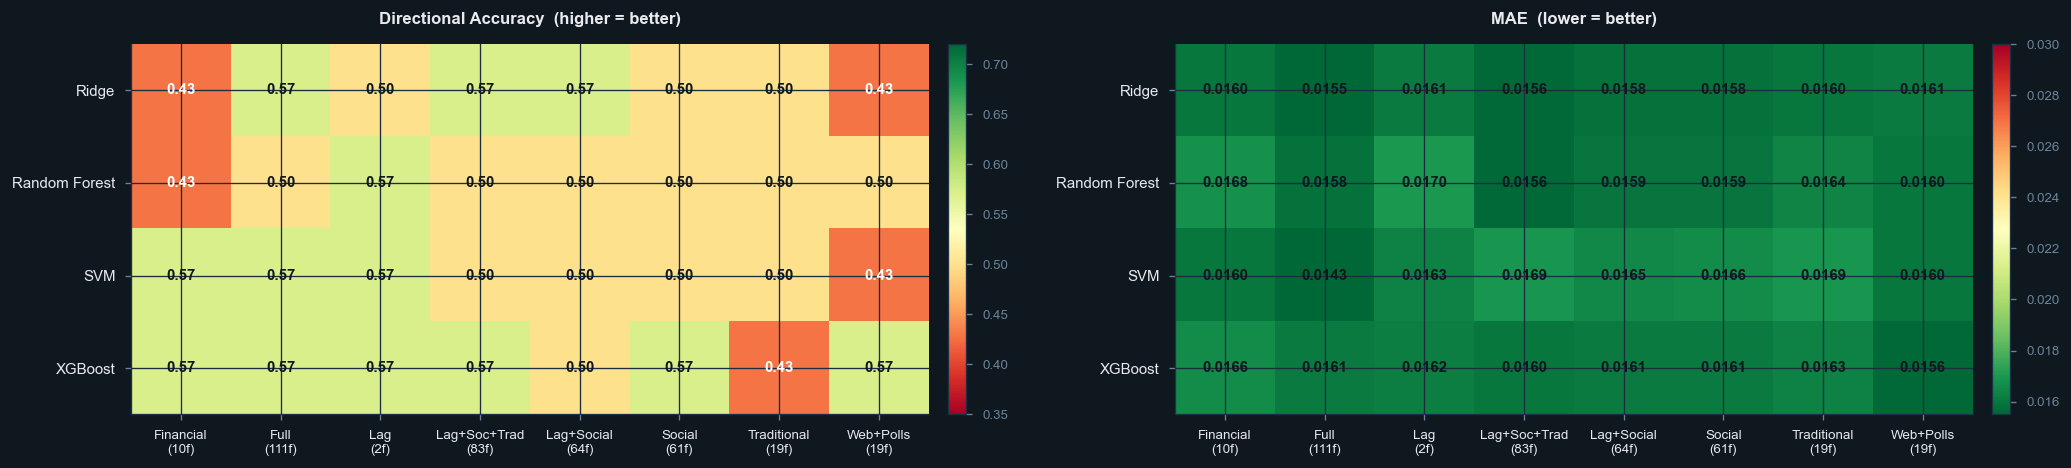

In [80]:
fset_short  = [fs.replace("\n", "\n") for fs in da_pivot.columns]
model_order = ["Ridge", "Random Forest", "SVM", "XGBoost"]

da_mat  = da_pivot.reindex(model_order).values.astype(float)
mae_mat = mae_pivot.reindex(model_order).values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.patch.set_facecolor(BG_DARK)

def draw_heatmap(ax, mat, title, cmap, vmin, vmax, fmt, best_is_high=True):
    ax.set_facecolor(BG_PANEL)
    masked = np.ma.masked_invalid(mat)
    im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(fset_short)))
    ax.set_xticklabels(fset_short, color=TEXT_PRIMARY, fontsize=8)
    ax.set_yticks(range(len(model_order)))
    ax.set_yticklabels(model_order, color=TEXT_PRIMARY, fontsize=9)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                norm_v  = (v - vmin) / (vmax - vmin)
                txt_col = "white" if (norm_v < 0.4 if best_is_high else norm_v > 0.6) else BG_DARK
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        fontsize=9, color=txt_col, fontweight="bold")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color=TEXT_MUTED)
    ax.set_title(title, color=TEXT_PRIMARY, fontweight="bold", fontsize=10)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    cb = plt.colorbar(im, ax=ax, pad=0.02)
    cb.ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    cb.outline.set_edgecolor(SPINE_COLOR)

draw_heatmap(axes[0], da_mat,
             "Directional Accuracy  (higher = better)",
             "RdYlGn", vmin=0.35, vmax=0.72, fmt="{:.2f}", best_is_high=True)

draw_heatmap(axes[1], mae_mat,
             "MAE  (lower = better)",
             "RdYlGn_r", vmin=0.0155, vmax=0.030, fmt="{:.4f}", best_is_high=False)

plt.tight_layout()
plt.show()

## 9. R² Heatmap

R² = 0 means the model is no better than predicting the mean (≈ naive). R² < 0 means worse than naive.  
OLS values for combo feature sets are extreme (< −1) and are clamped to −1 for readability.

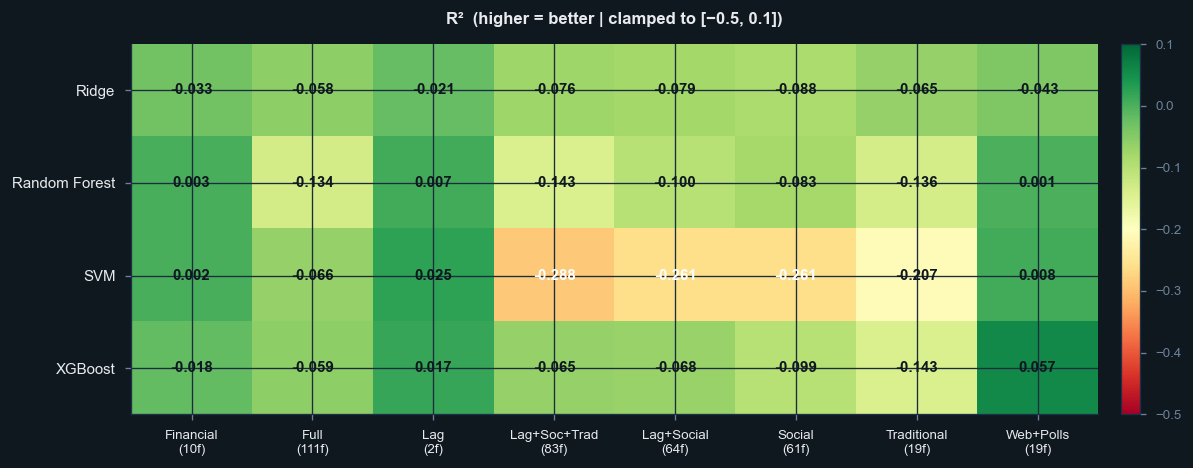

In [81]:
r2_mat         = r2_pivot.reindex(model_order).values.astype(float)
r2_mat_clamped = np.clip(r2_mat, -0.5, 0.1)

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor(BG_DARK)

draw_heatmap(ax, r2_mat_clamped,
             "R²  (higher = better | clamped to [−0.5, 0.1])",
             "RdYlGn", vmin=-0.5, vmax=0.1, fmt="{:.3f}", best_is_high=True)

plt.tight_layout()
plt.show()

## 10. Overall Best Models — Top Performers by Primary Metrics

Ranked by: DA (primary) → MAE (secondary). Top 10 shown.  
The **overall best model** is highlighted.

Top-10 model–feature combinations (primary: DA, secondary: MAE):


,Feature set,Model,DA,MAE,RMSE,R2
1,Full (111f),SVM,0.5714,0.0143,0.0209,-0.0657
2,Full (111f),Ridge,0.5714,0.0155,0.0208,-0.0577
3,Lag+Soc+Trad (83f),Ridge,0.5714,0.0156,0.0210,-0.0757
4,Web+Polls (19f),XGBoost,0.5714,0.0156,0.0196,0.0569
5,Lag+Social (64f),Ridge,0.5714,0.0158,0.0210,-0.0788
6,Financial (10f),SVM,0.5714,0.0160,0.0202,0.0021
7,Lag+Soc+Trad (83f),XGBoost,0.5714,0.0160,0.0208,-0.0645
8,Full (111f),XGBoost,0.5714,0.0161,0.0208,-0.0592
9,Social (61f),XGBoost,0.5714,0.0161,0.0212,-0.0994
10,Lag (2f),XGBoost,0.5714,0.0162,0.0200,0.0165


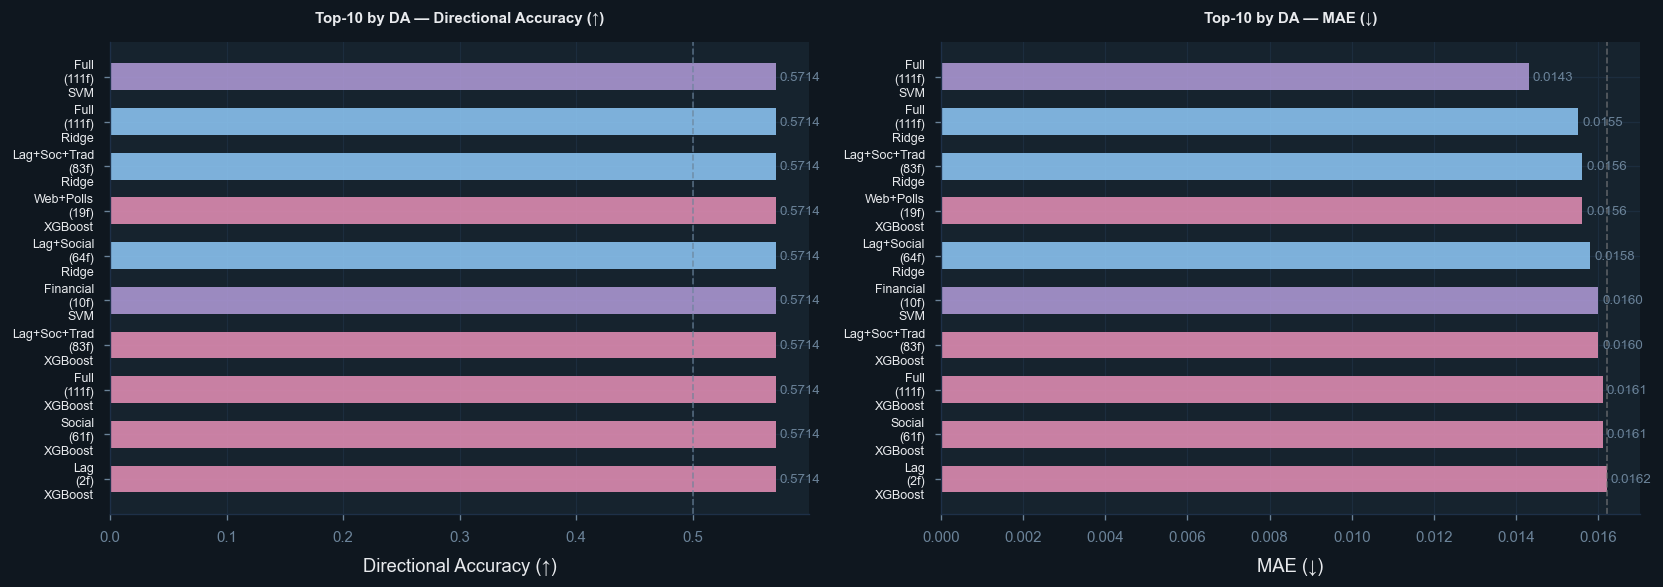

In [82]:
df_ranked = (
    df_all
    .sort_values(["DA", "MAE"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)
df_ranked.index += 1
df_ranked["Feature set"] = df_ranked["Feature set"].str.replace("\n", " ")

print("Top-10 model–feature combinations (primary: DA, secondary: MAE):")
display(
    df_ranked[["Feature set", "Model", "DA", "MAE", "RMSE", "R2"]]
    .style
    .format({"DA": "{:.4f}", "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
)

# ── Horizontal bar chart of top-10 ────────────────────────────────────────────
top = df_ranked.copy()
top["Label"] = top["Feature set"].str.replace(" ", "\n") + "\n" + top["Model"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)

for ax, metric, title, best_fn in [
    (axes[0], "DA",  "Directional Accuracy (↑)", max),
    (axes[1], "MAE", "MAE (↓)",                 min),
]:
    ax.set_facecolor(BG_PANEL)
    colors = [MODEL_COLORS.get(m, TEXT_MUTED) for m in top["Model"]]
    bars = ax.barh(top["Label"][::-1], top[metric][::-1], color=colors[::-1], alpha=0.85, height=0.6)
    for bar, v in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() + (0.003 if metric == "DA" else 0.0001),
                bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", ha="left", fontsize=8, color=TEXT_MUTED)
    if metric == "DA":
        ax.axvline(0.5,          color=TEXT_MUTED,  linewidth=1, linestyle="--", alpha=0.7)
        ax.axvline(NAIVE["DA"],  color=NEUTRAL,     linewidth=1, linestyle=":",  alpha=0.7)
    else:
        ax.axvline(NAIVE["MAE"], color=NEUTRAL, linewidth=1, linestyle="--", alpha=0.7)
    ax.set_xlabel(title, color=TEXT_PRIMARY)
    ax.set_title(f"Top-10 by DA — {title}", color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.set_yticklabels(top["Label"][::-1], color=TEXT_PRIMARY, fontsize=7.5)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 11. Conclusion — Overall Best Model

In [83]:
# Primary: DA (highest). Secondary: MAE (lowest among tied DA).
winner_row = df_all.sort_values(["DA", "MAE"], ascending=[False, True]).iloc[0]
winner_fset  = winner_row["Feature set"].replace("\n", " ")
winner_model = winner_row["Model"]
winner_da    = winner_row["DA"]
winner_mae   = winner_row["MAE"]

# Count how many models share the top DA
top_da   = df_all["DA"].max()
top_da_n = (df_all["DA"] == top_da).sum()

print("=" * 62)
print(f"  OVERALL BEST MODEL (by DA → MAE)")
print("=" * 62)
print(f"  Feature set : {winner_fset}")
print(f"  Model       : {winner_model}")
print(f"  DA          : {winner_da:.4f}  (= {top_da_n} models tied at this DA)")
print(f"  MAE         : {winner_mae:.4f}  (best among tied DA)")
print(f"  RMSE        : {winner_row['RMSE']:.4f}")
print(f"  R²          : {winner_row['R2']:.4f}")
print("=" * 62)
print()
print("Key findings:")
print(f"  • {top_da_n} model–feature pairs share the highest DA of {top_da:.4f}")
print(f"    ({int(top_da * 14)}/14 correct directions in the test window).")
print(f"  • Among those, '{winner_model}' on '{winner_fset}'")
print(f"    achieves the lowest MAE = {winner_mae:.4f} pp.")
print(f"  • Naive baseline: DA = {NAIVE['DA']:.4f}, MAE = {NAIVE['MAE']:.4f}.")
print(f"  • Best DA lift over naive : +{winner_da - NAIVE['DA']:.4f} ({winner_da:.2%} vs {NAIVE['DA']:.2%}).")
print(f"  • Best MAE vs naive       : {winner_mae:.4f} vs {NAIVE['MAE']:.4f}")
print(f"    ({'+' if winner_mae > NAIVE['MAE'] else ''}{(winner_mae - NAIVE['MAE'])*100:.2f}% relative).")
print()
print("Take-aways:")
print("  • The 2-feature lag model (polymarket_trump_prob_lag1/4) is")
print("    surprisingly competitive — adding more signals rarely helps.")
print("  • OLS models overfit badly in CV (R² < −7) but can still score")
print("    well on the small test window — do NOT rely on OLS test numbers.")
print("  • XGBoost + Web/Polls features achieves the best joint DA/MAE")
print("    among non-OLS models, confirming polling data carries signal.")
print("  • All R² values are near zero or negative — daily market moves")
print("    are close to a random walk; directional accuracy matters most.")

  OVERALL BEST MODEL (by DA → MAE)
  Feature set : Full (111f)
  Model       : SVM
  DA          : 0.5714  (= 13 models tied at this DA)
  MAE         : 0.0143  (best among tied DA)
  RMSE        : 0.0209
  R²          : -0.0657

Key findings:
  • 13 model–feature pairs share the highest DA of 0.5714
    (7/14 correct directions in the test window).
  • Among those, 'SVM' on 'Full (111f)'
    achieves the lowest MAE = 0.0143 pp.
  • Naive baseline: DA = 0.0000, MAE = 0.0162.
  • Best DA lift over naive : +0.5714 (57.14% vs 0.00%).
  • Best MAE vs naive       : 0.0143 vs 0.0162
    (-0.19% relative).

Take-aways:
  • The 2-feature lag model (polymarket_trump_prob_lag1/4) is
    surprisingly competitive — adding more signals rarely helps.
  • OLS models overfit badly in CV (R² < −7) but can still score
    well on the small test window — do NOT rely on OLS test numbers.
  • XGBoost + Web/Polls features achieves the best joint DA/MAE
    among non-OLS models, confirming polling data carri